In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
uploaded = files.upload()
#pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


# fetch dataset
df = pd.read_csv("sleep_mobile_stress_dataset_15000.csv")
df.columns


Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='object')

In [ ]:
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [ ]:
df.shape

(15000, 13)

In [ ]:
df.isnull().sum()
#Sem valores nulos

,0
user_id,0
age,0
gender,0
occupation,0
daily_screen_time_hours,0
phone_usage_before_sleep_minutes,0
sleep_duration_hours,0
sleep_quality_score,0
stress_level,0
caffeine_intake_cups,0


In [ ]:
df.duplicated().sum()
#Sem valores duplicados

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [ ]:
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [ ]:
df.describe(include="object")
#
#top: Categoria que ocorre com maior frequência
#freq: Número de observações do top

,gender,occupation
count,15000,15000
unique,3,8
top,Male,Manager
freq,7234,1962


In [ ]:
df['gender'].value_counts()

,count
gender,
Male,7234
Female,7181
Other,585


In [ ]:
df['occupation'].value_counts()

,count
occupation,
Manager,1962
Doctor,1922
Software Engineer,1917
Freelancer,1891
Student,1861
Researcher,1837
Designer,1813
Teacher,1797


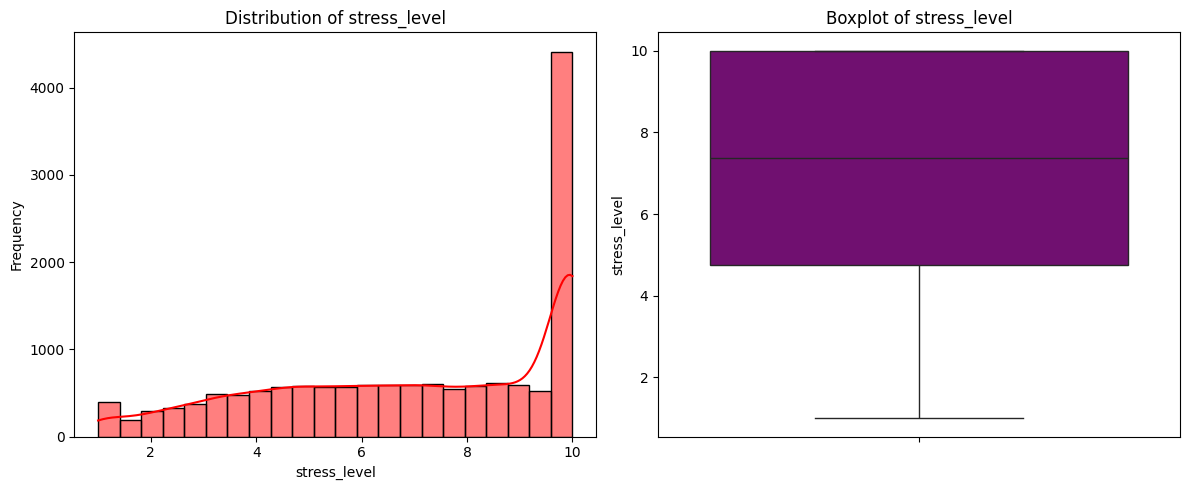

In [ ]:
def plot_distribution(data, column):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.histplot(data[column], kde=True, color="red")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.subplot(1,2,2)
    sns.boxplot(y=data[column], color="purple")
    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()


plot_distribution(df, "stress_level")


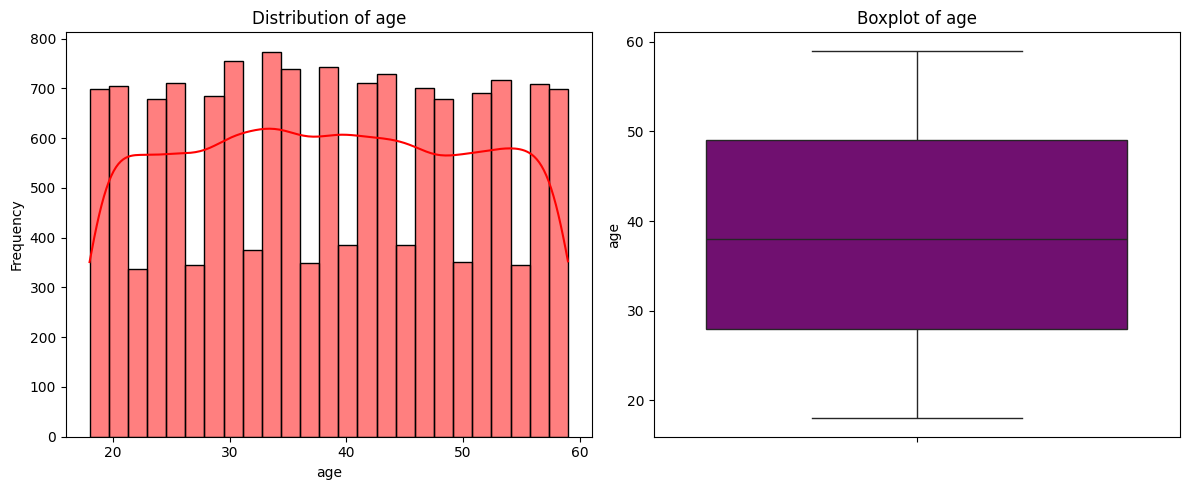

In [ ]:
plot_distribution(df, "age")

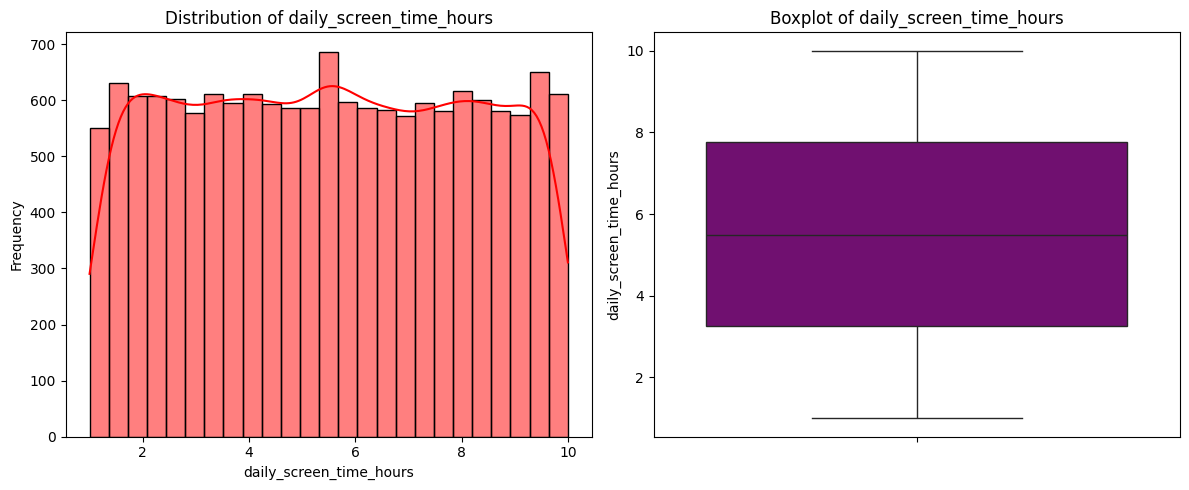

In [ ]:
plot_distribution(df, "daily_screen_time_hours")

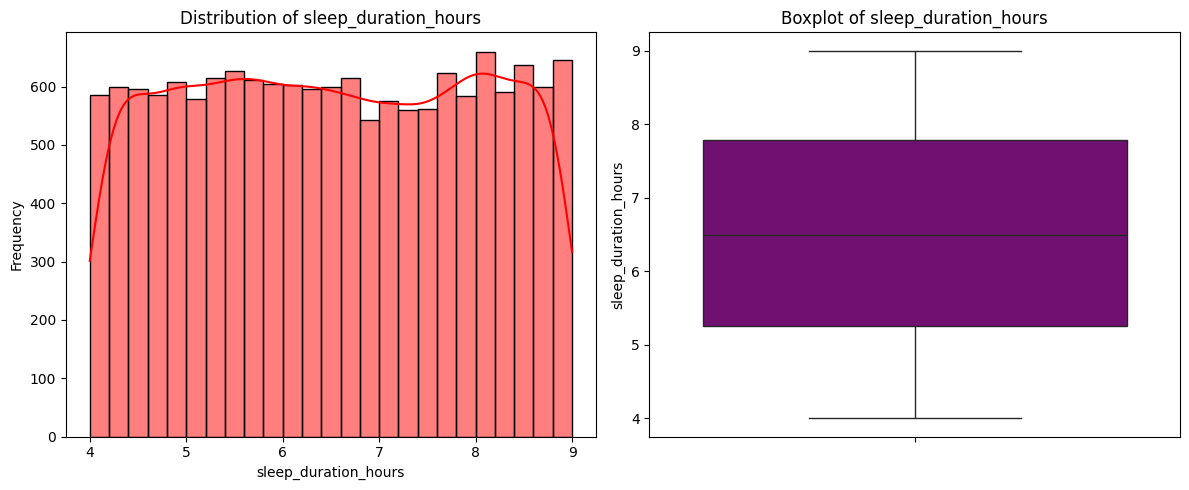

In [ ]:
plot_distribution(df, "sleep_duration_hours")

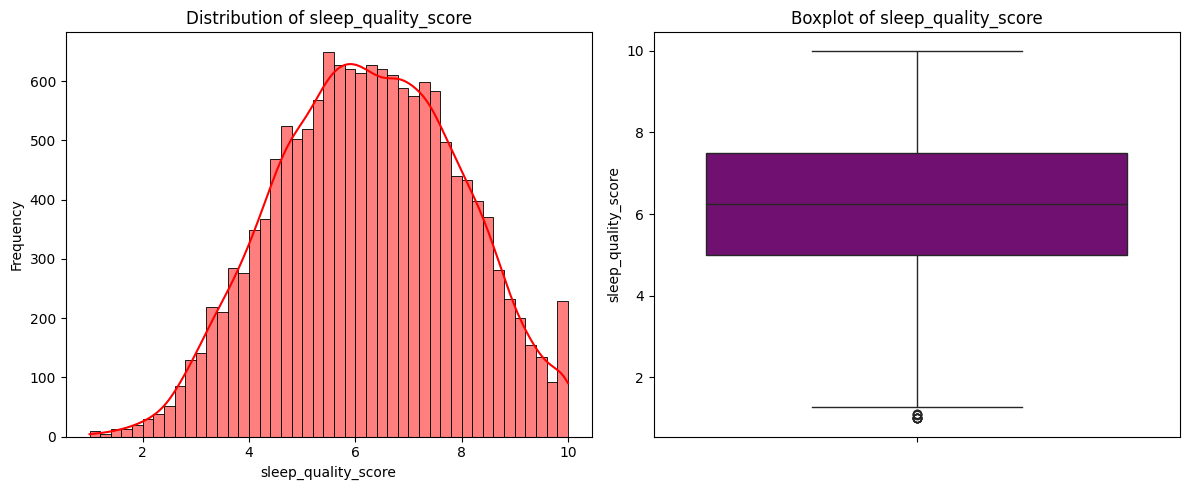

In [ ]:
plot_distribution(df, "sleep_quality_score")

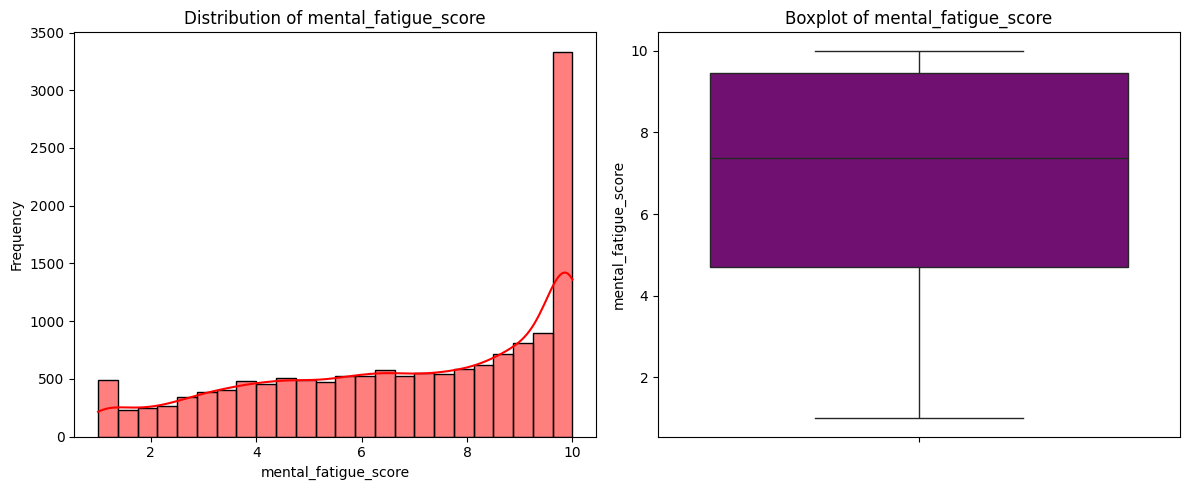

In [ ]:
plot_distribution(df, "mental_fatigue_score")

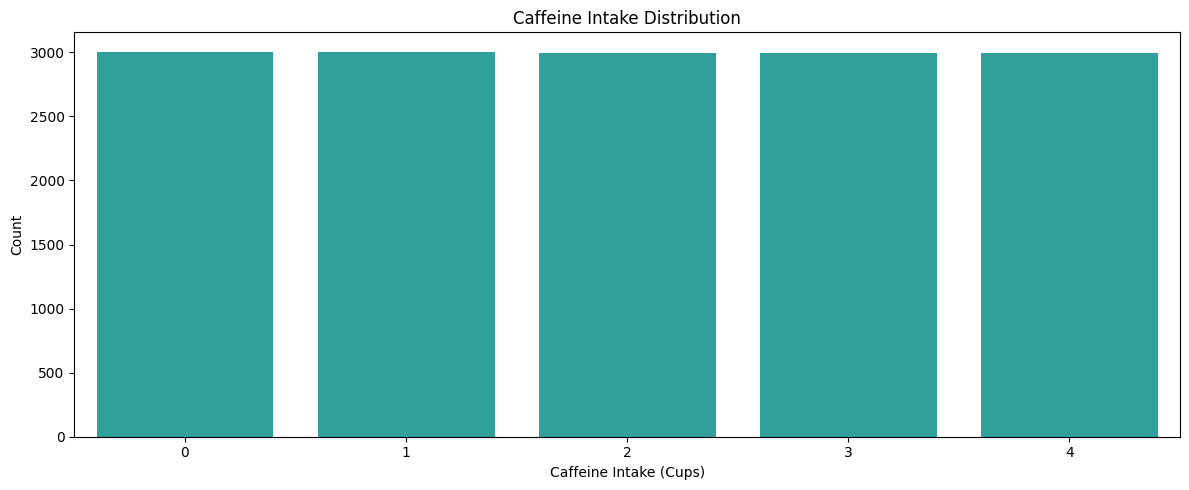

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(x=df["caffeine_intake_cups"], color="lightseagreen")
plt.title("Caffeine Intake Distribution")
plt.xlabel("Caffeine Intake (Cups)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

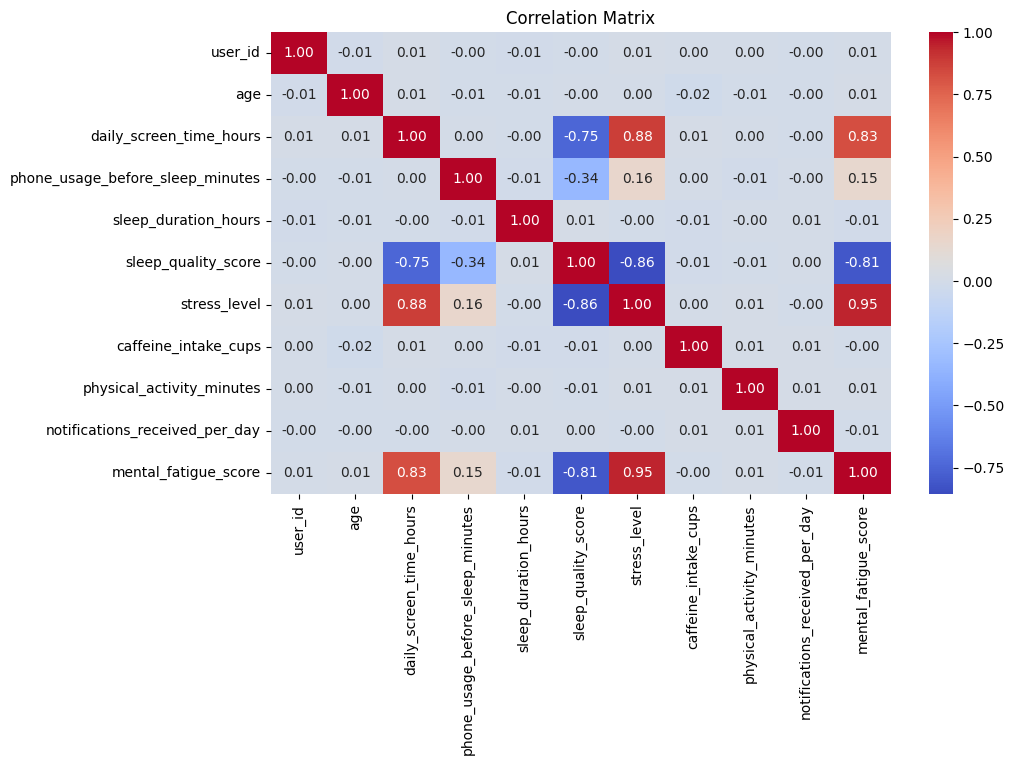

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

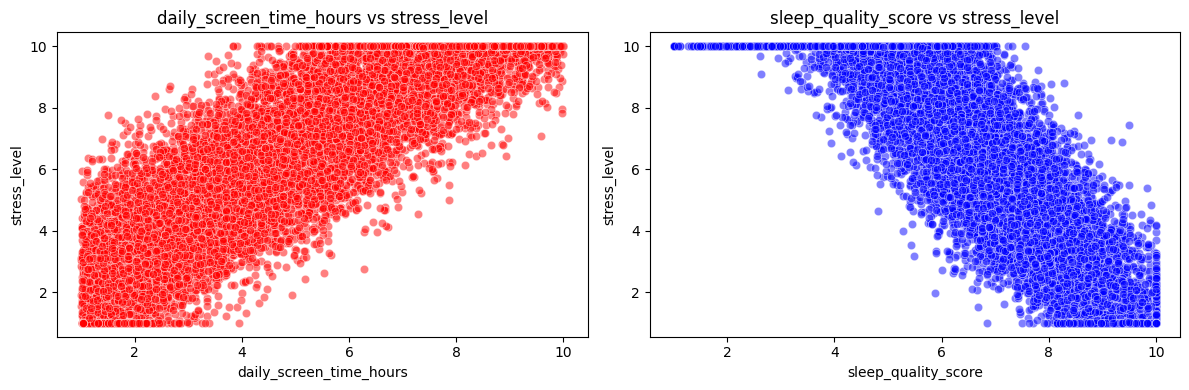

In [ ]:
#Algumas correlações elevadas com  o nosso target
def plot_scatter_pair(df, x1, x2, y="stress_level"):

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.scatterplot(x=x1, y=y, data=df,   color="red", alpha=0.5)
    plt.title(f"{x1} vs {y}")
    plt.xlabel(x1)
    plt.ylabel(y)

    plt.subplot(1,2,2)
    sns.scatterplot(x=x2, y=y, data=df, alpha=0.5,  color="blue",)
    plt.title(f"{x2} vs {y}")
    plt.xlabel(x2)
    plt.ylabel(y)

    plt.tight_layout()
    plt.show()

plot_scatter_pair(df, "daily_screen_time_hours", "sleep_quality_score")

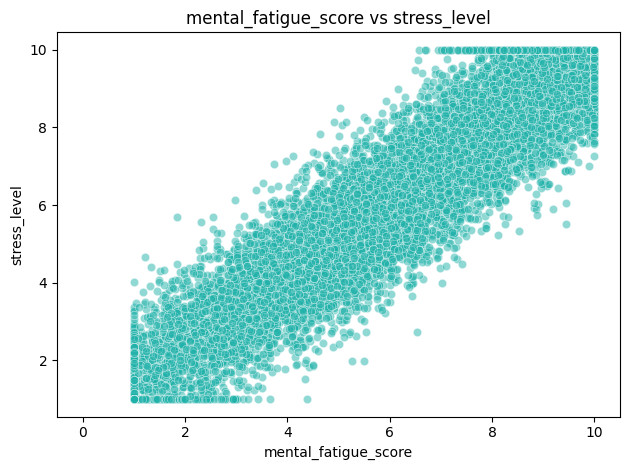

In [ ]:
plt.plot(1,2,2)
sns.scatterplot(x='mental_fatigue_score', y='stress_level', data=df, alpha=0.5,  color="lightseagreen",)
plt.title(f"mental_fatigue_score vs stress_level")
plt.xlabel("mental_fatigue_score")
plt.ylabel("stress_level")

plt.tight_layout()
plt.show()